# Brain Tumor MRI Classification - Classical Machine Learning

This notebook builds an end-to-end image-classification pipeline using classical machine-learning methods.

We will:

1. download and inspect the MRI dataset,
2. convert the images into numerical features,
3. compare raw pixels with HOG features,
4. train several classical classifiers,
5. tune selected models with `GridSearchCV`,
6. evaluate the best model on an untouched test set,
7. inspect the model's errors.

The task is binary classification: determine whether an MRI image contains a tumor (`tumor`) or does not contain a tumor (`no_tumor`).

In [1]:
import kagglehub
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
roc_auc_score,
RocCurveDisplay,
)
import joblib

/opt/miniconda3/envs/brainenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 42
np.random.seed(random_state)
random.seed(random_state)

## Unpacking and Preparing the Data

The dataset is downloaded from Kaggle and organized into separate `Training` and `Testing` directories. Each directory contains one subfolder per original MRI class.

At this stage we create reusable paths and verify that the expected folders exist before loading any images.

In [3]:
DATA_DIR = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))

TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

print(TRAIN_DIR.exists(), TEST_DIR.exists())
print(list(TRAIN_DIR.iterdir()))


True True
[PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/pituitary'), PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/notumor'), PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/glioma'), PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma')]


In [4]:
# DataFrame
TUMOR_CLASSES = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
NO_TUMOR_CLASS = "notumor"
 

def binary_label(orginal_label: str) -> int:
    if orginal_label == NO_TUMOR_CLASS:
        return 0
    else:        return 1
    
#

## Building a DataFrame

A DataFrame gives us one structured record per image. For every file we store its path, original class name, binary target value, and readable binary target name.

This makes the later preprocessing, splitting, visualization, and error analysis easier to reproduce.

In [5]:
def build_dataframe(split_dir: Path) -> pd.DataFrame:
    data = []                                    # Empty list to which we will add the data.
    for class_dir in split_dir.iterdir():        # Iterate over the class folders.
        orginal_label = class_dir.name           # The folder name is our label.
        
        if orginal_label == "notumor":
            binary_label_value = 0
            binary_label_name = "no_tumor"
        else:
            binary_label_value = 1
            binary_label_name = "tumor"

        for image_path in class_dir.iterdir():  # Iterate over the files in the folder.
            data.append(
                {
                    "image_path": image_path,
                    "original_label": orginal_label,
                    "binary_label_value": binary_label_value,
                    "binary_label_name": binary_label_name,
                }
            )
    return pd.DataFrame(data)                  # Create a DataFrame from the data list.

full_train_df = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)
display(full_train_df.head(20))
display(full_train_df["binary_label_name"].value_counts())
display(test_df["binary_label_name"].value_counts())


,image_path,original_label,binary_label_value,binary_label_name
0,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
1,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
2,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
3,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
4,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
5,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
6,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
7,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
8,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor
9,/Users/anielka/.cache/kagglehub/datasets/masou...,pituitary,1,tumor


binary_label_name
tumor       4200
no_tumor    1400
Name: count, dtype: int64

binary_label_name
tumor       1200
no_tumor     400
Name: count, dtype: int64

## Train / Validation Split

The original training data is divided into two parts:

- **training set** - used to fit model parameters,
- **validation set** - used to compare models and choose settings.

The split is stratified, so both subsets preserve approximately the same proportion of tumor and no-tumor images. The separate test set remains untouched until the final evaluation.

we use `train_test_split`
- test_size - parameter that determines what percentage of the data goes to the validation set (20% here).
- stratify - parameter that preserves class proportions in both sets, so train and validation contain similar numbers of samples from each class.
- Both parts have a similar class distribution, which is important for training the model.


In [6]:

train_df, val_df = train_test_split(full_train_df, test_size=0.2, stratify=full_train_df["binary_label_value"], random_state=random_state)

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

print("\nTrain set distribution:")
print(train_df["binary_label_name"].value_counts())
print("\nValidation set distribution:")
print(val_df["binary_label_name"].value_counts())
print("\nTest set distribution:")
print(test_df["binary_label_name"].value_counts())

train_df shape: (4480, 4)
val_df shape: (1120, 4)
test_df shape: (1600, 4)

Train set distribution:
binary_label_name
tumor       3360
no_tumor    1120
Name: count, dtype: int64

Validation set distribution:
binary_label_name
tumor       840
no_tumor    280
Name: count, dtype: int64

Test set distribution:
binary_label_name
tumor       1200
no_tumor     400
Name: count, dtype: int64


## Class Distribution

Before training, we check how many images belong to each binary class in the training, validation, and test sets.

This is an important sanity check: a strong imbalance can affect accuracy and may require class weighting or a more careful choice of evaluation metrics.

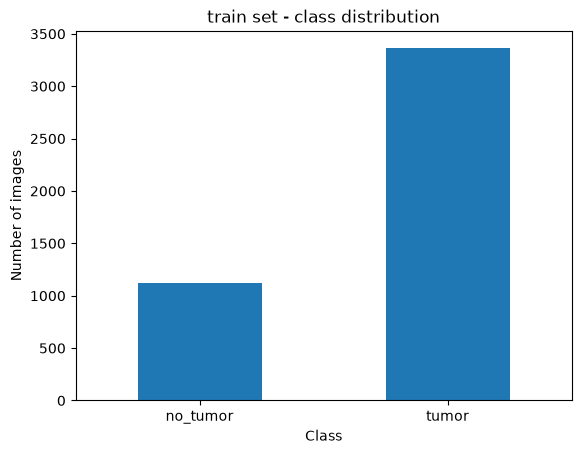

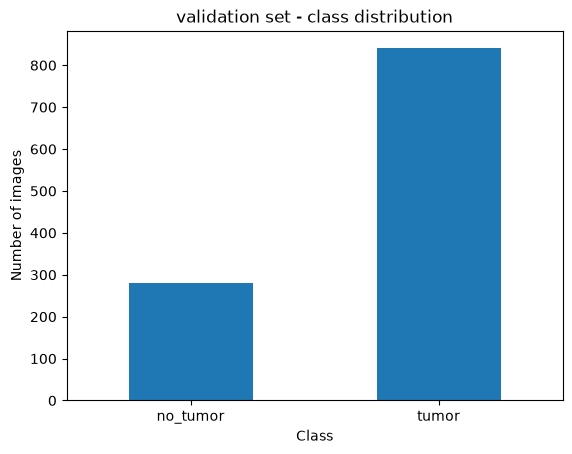

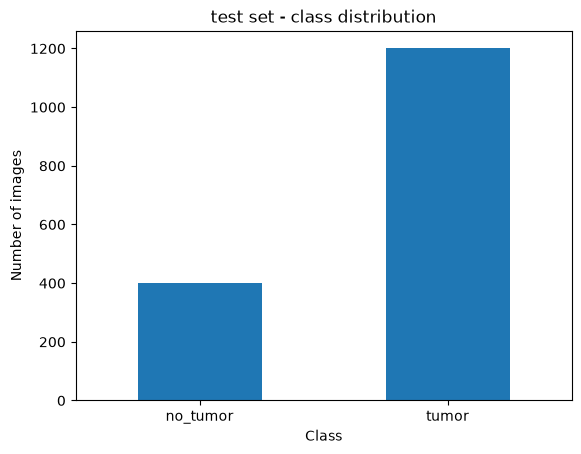

In [7]:
def plot_class_distribution(df: pd.DataFrame, title: str):
    counts = df["binary_label_name"].value_counts().sort_index()  # Sort class labels alphabetically for a clearer chart.
    ax = counts.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    plt.xticks(rotation=0)  # Keep class labels horizontal on the x-axis.
    plt.show()
plot_class_distribution(train_df, "train set - class distribution")
plot_class_distribution(val_df, "validation set - class distribution")
plot_class_distribution(test_df, "test set - class distribution")


## Example Images

We display a random sample of MRI images together with their original and binary labels.


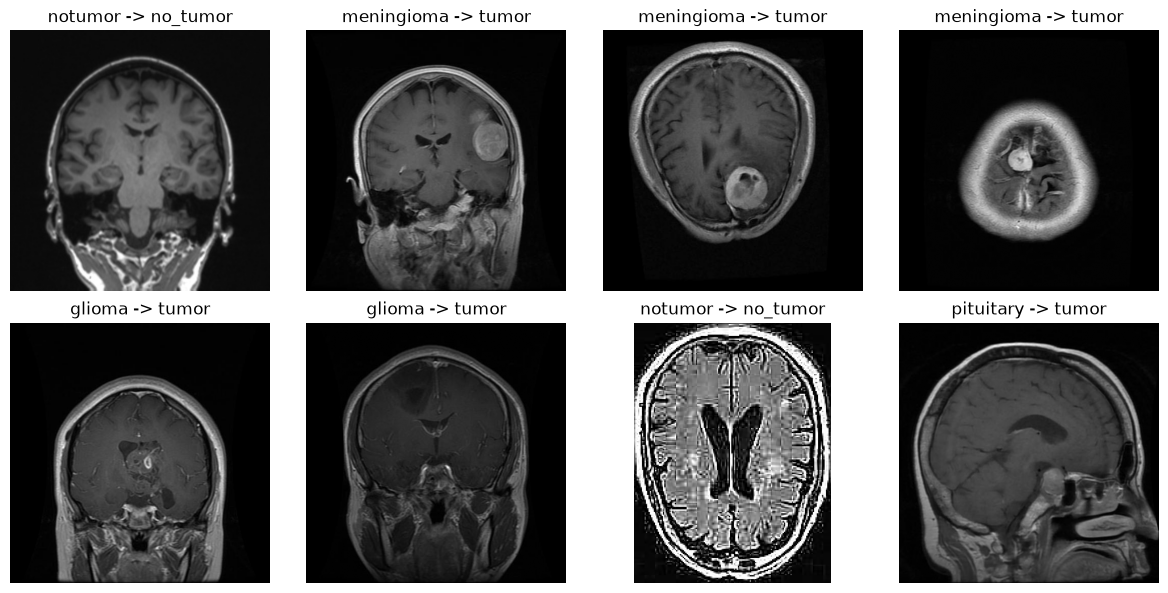

In [ ]:
def show_random_images(df: pd.DataFrame, n: int = 8):
    sample = df.sample(n=n, random_state=random_state)          # Randomly select n images from the DataFrame.

    plt.figure(figsize=(12, 6))  # Set the figure size.
    for i, (_, row) in enumerate(sample.iterrows(), start=1):   # Iterate over the sampled images
        image = imread(row["image_path"]) 

        plt.subplot(2, 4, i)
        plt.imshow(image, cmap="gray")
        plt.title(f"{row['original_label']} -> {row['binary_label_name']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_random_images(train_df, n=8)


## Checking Image Dimensions

Classical machine-learning models expect every sample to have the same number of input features. We inspect image dimensions before choosing a common resizing strategy.

In [ ]:
def get_image_shape(path: str):
    qimage = imread(path)           # Load the image from the given path into a NumPy array.
    return qimage.shape             # Return the image dimensions (height, width, number of channels).

sample_shapes = train_df.sample(200, random_state=random_state)["image_path"].apply(get_image_shape)  
shape_counts = sample_shapes.value_counts().head(10)  # Count unique shapes and keep the 10 most common ones.
print(shape_counts)

image_path
(512, 512)        80
(512, 512, 3)     67
(225, 225, 3)      8
(442, 442, 3)      3
(236, 236, 3)      3
(198, 150, 3)      2
(221, 228, 3)      2
(417, 428, 3)      2
(830, 1024, 3)     1
(217, 232, 3)      1
Name: count, dtype: int64


## Image Preprocessing

Each image is converted to grayscale when necessary and resized to `128 x 128` pixels.

The result is a consistent floating-point representation with pixel values in the `[0, 1]` range. This removes differences in image shape and prepares the data for feature extraction.

(128, 128) 0.0 0.813567


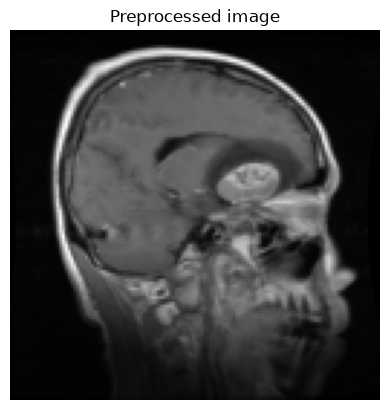

In [8]:
IMAGE_SIZE = (128, 128)

def load_and_preprocess_image(path: str, image_size=IMAGE_SIZE) -> np.ndarray:
    """Load image, convert to grayscale, resize and return float array.""" 
    image = imread(path)

    # Check whether the image is color (3 dimensions: height, width, number of channels).
    # If so, convert it to grayscale.
    if image.ndim == 3:                 # Check whether the image is color; ndim returns the number of dimensions.
        if image.shape[-1] == 4:        # If the image has 4 channels (e.g. RGBA), keep only the first 3 (RGB).
            image = image[..., :3]      # Keep only the first 3 channels because alpha is not needed.
        image = rgb2gray(image)         # Convert the RGB image to grayscale.


    

    image_resized = resize(             # Resize the image and normalize values to the [0, 1] range.
        image,
        image_size,
        anti_aliasing=True,             # Avoid aliasing artifacts during image resizing.
        preserve_range=False,           # Normalize pixel values to the [0, 1] range.
    )
    return image_resized.astype(np.float32)  # Return the image as a float32 NumPy array.

example_path = train_df.iloc[0]["image_path"]  # Select the image path from the first row of train_df.
example_image = load_and_preprocess_image(example_path) 
print(example_image.shape, example_image.min(), example_image.max())  # Check image shape and value range.

plt.imshow(example_image, cmap="gray")
plt.title("Preprocessed image")
plt.axis("off")
plt.show()

## Representing an Image as Numbers

A machine-learning model cannot work directly with an image file. It needs a numerical feature vector.

We create a baseline representation by flattening the preprocessed image into one long vector of raw pixel intensities.

In [9]:
def extract_raw_pixels(path: str) -> np.ndarray:
    image = load_and_preprocess_image(path)
    return image.ravel()                    # Flatten the array from (128, 128) to (16384,).

raw_features = extract_raw_pixels(example_path)
print(raw_features.shape)


(16384,)


## HOG Features: Histogram of Oriented Gradients

HOG is a hand-crafted feature representation that describes local edge directions rather than absolute pixel brightness. This is useful because a tumor may be recognized through its shape and boundaries.

### How HOG works

1. Compute horizontal and vertical image gradients.
2. Convert the gradients into magnitude and direction.
3. Divide the image into small cells.
4. Build an orientation histogram for each cell.
5. Normalize neighboring cells in blocks.
6. Concatenate the normalized histograms into one feature vector.

HOG is often useful for classical models because it reduces the image to structural information while keeping the feature space manageable.

### Advantages

- Simple and interpretable feature extraction.
- Fast to compute.
- Focuses on contours and local shapes.

### Limitations

- Sensitive to large rotations and scale changes.
- Does not learn features automatically.
- Usually less flexible than modern convolutional neural networks.

### HOG Feature-Extraction Parameters

The next cell defines the HOG settings used throughout the notebook. These parameters control the angular resolution, cell size, block size, and normalization method.

In [10]:
HOG_PARAMS = { 
"orientations": 9,          # Number of gradient orientations considered when creating the histogram.
"pixels_per_cell": (8, 8),  # Cell size for the gradient orientation histogram.
"cells_per_block": (2, 2),  # Number of cells in each block used to create the histogram.
"block_norm": "L2-Hys",     # Block normalization method using the L2 norm and clipping.
}


### Extracting and Visualizing HOG Features

We calculate the HOG vector for one example image and visualize the corresponding HOG image. This provides a quick check that the feature extractor is responding to meaningful edges and structures.

(8100,)


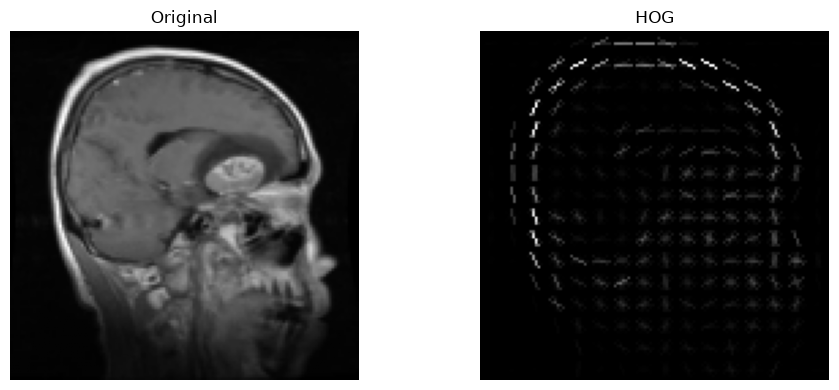

In [11]:
def extract_hog_features(path: str, visualize: bool = False): 
    image = load_and_preprocess_image(path)

    if visualize: 
        features, hog_image = hog(
            image,
            **HOG_PARAMS,
            visualize=True, 
            feature_vector=True,
        )
        return features, hog_image

    features = hog(
        image,
        **HOG_PARAMS,
        visualize=False,
        feature_vector=True,
    )
    return features

hog_features, hog_image = extract_hog_features(example_path, visualize=True) 
print(hog_features.shape)

# Visualize HOG features.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(example_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# HOG returns an image visualizing the features. Its values can be large, so rescale them to [0, 1] for display.
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10)) 

axes[1].imshow(hog_image_rescaled, cmap="gray")  # Display the rescaled HOG feature image.
axes[1].set_title("HOG")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Building the Feature Matrices

The feature-extraction functions are applied to every image in the training, validation, and test sets.

We build HOG matrices and matching target vectors. These matrices are the inputs used by the classical classifiers.
Function for building a feature matrix and label vector from a DataFrame. It iterates over image paths,
extracts features (HOG or raw pixels) from each image, adds them to X, adds binary labels to y,
and returns the feature matrix X and label vector y.

In [12]:
def build_feature_matrix(df: pd.DataFrame, feature_type: str = "hog"):
    X = []
    y = df["binary_label_value"].to_numpy()

    for path in tqdm(df["image_path"], desc=f"Extracting {feature_type} features"):  # Show a progress bar while extracting features.
        if feature_type == "hog":  # Extract HOG features when the selected feature type is "hog".
            features = extract_hog_features(path)
        elif feature_type == "raw":
            features = extract_raw_pixels(path)
        X.append(features)

    X = np.vstack(X)  # Combine the list of arrays into one feature matrix.
    return X, y


X_train_hog, y_train = build_feature_matrix(train_df, feature_type="hog")  # Build HOG features and labels for the training set.
X_val_hog, y_val = build_feature_matrix(val_df, feature_type="hog")
X_test_hog, y_test = build_feature_matrix(test_df, feature_type="hog")

print("Training set shape:", X_train_hog.shape, y_train.shape)  # Check the feature matrix and label vector shapes.
print("Validation set shape:", X_val_hog.shape, y_val.shape)
print("Test set shape:", X_test_hog.shape, y_test.shape)

Extracting hog features:   0%|          | 0/4480 [00:00<?, ?it/s]

Extracting hog features: 100%|██████████| 1600/1600 [00:07<00:00, 223.20it/s]

Training set shape: (4480, 8100) (4480,)
Validation set shape: (1120, 8100) (1120,)
Test set shape: (1600, 8100) (1600,)


### Previewing HOG Features

Before training, we inspect a small part of the HOG matrix. This confirms its tabular structure: rows represent images and columns represent extracted features.

In [13]:
# Create a DataFrame from the first 10 rows of the HOG feature matrix and add binary labels.
hog_preview_df = pd.DataFrame(
    X_train_hog[:10, :20],
    columns=[f"hog_{i}" for i in range(20)]
)

hog_preview_df["target"] = y_train[:10]
hog_preview_df

,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,hog_11,hog_12,hog_13,hog_14,hog_15,hog_16,hog_17,hog_18,hog_19,target
0,0.008656,0.072037,0.034090,3.161694e-01,0.316169,0.111710,0.070458,0.018999,0.000000,0.007135,...,0.005278,0.107872,3.161694e-01,0.080413,0.086695,0.093069,0.019628,0.239405,0.073520,1
1,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.506947,...,0.000000,0.000000,1.733886e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,0.141944,0.025446,0.009485,1.497032e-01,0.363809,0.169415,0.056596,0.341847,0.062237,0.036297,...,0.049845,0.232675,3.638085e-01,0.101383,0.027063,0.074221,0.048214,0.037126,0.000000,1
3,0.046781,0.013602,0.065740,2.825388e-01,0.282539,0.201994,0.087393,0.039148,0.031436,0.023906,...,0.042468,0.073259,2.825388e-01,0.109684,0.005605,0.074497,0.012299,0.183243,0.252513,1
4,0.486745,0.226230,0.000000,2.361650e-02,0.486745,0.018266,0.004265,0.014399,0.004596,0.000000,...,0.000000,0.000000,4.867449e-01,0.000000,0.000000,0.000000,0.000000,0.486745,0.000000,0
5,0.233284,0.011366,0.040663,1.035763e-07,0.049135,0.114559,0.148756,0.083089,0.109958,0.261847,...,0.261847,0.250978,7.182224e-02,0.154395,0.066066,0.134542,0.238118,0.261847,0.030854,0
6,0.078479,0.025080,0.038778,3.264147e-01,0.370996,0.000000,0.076498,0.024023,0.124094,0.224933,...,0.008579,0.370996,3.709963e-01,0.249427,0.131719,0.000000,0.108654,0.146051,0.159278,1
7,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.009683,...,0.087154,0.000000,9.654010e-03,0.000000,0.075637,0.000000,0.414046,0.000000,0.000000,1
8,0.364811,0.157236,0.042398,1.772979e-01,0.368301,0.000000,0.000000,0.001853,0.100991,0.000001,...,0.000000,0.196795,3.683007e-01,0.133896,0.079612,0.020901,0.042259,0.368301,0.138672,1
9,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.309455,...,0.000000,0.000033,1.445529e-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1


## Establishing a Baseline

A `DummyClassifier` provides a deliberately simple reference point. It always predicts the most frequent class.

A useful model should clearly outperform this baseline. Otherwise, its apparent accuracy may come only from the class distribution rather than from learning meaningful image patterns.

In [16]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=random_state)
dummy_clf.fit(X_train_hog, y_train)
y_val_pred_dummy = dummy_clf.predict(X_val_hog)
print("Dummy accuracy:", accuracy_score(y_val, y_val_pred_dummy))
print(classification_report(
    y_val,
    y_val_pred_dummy,
    target_names=["no_tumor", "tumor"],
    zero_division=0,  # Set undefined precision or recall to 0 when a class has no predictions.
))

Dummy accuracy: 0.75
              precision    recall  f1-score   support

    no_tumor       0.00      0.00      0.00       280
       tumor       0.75      1.00      0.86       840

    accuracy                           0.75      1120
   macro avg       0.38      0.50      0.43      1120
weighted avg       0.56      0.75      0.64      1120



## Classical Models Using HOG Features

We now compare several classical classifiers using the same HOG representation:

- Logistic Regression,
- Linear SVM,
- RBF SVM,
- Random Forest.

Keeping the feature representation fixed makes the model comparison easier to interpret.

### A Reusable Model-Evaluation Function

The helper function below applies the same evaluation procedure to every classifier:

1. fit the model on the training data,
2. predict the validation labels,
3. calculate accuracy,
4. display precision, recall, and F1-score,
5. plot the confusion matrix,
6. return the fitted model and predictions.

Using one function keeps the comparison consistent across all experiments.

In [17]:
def evaluate_model(name: str, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)  # Model predictions on the validation set.
    print("=" * 80)  # Print a separator line to distinguish the results of different models.
    print(name) 
    print("Accuracy:", accuracy_score(y_val, y_pred))  # Ratio of correct predictions to all predictions.
    print(classification_report(  # Classification report with precision, recall, f1-score, and support for each class.
        y_val,
        y_pred,
        target_names=["no_tumor", "tumor"],
        zero_division=0,
    ))
    
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1]) 
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["no_tumor", "tumor"],
    )
    disp.plot(values_format="d")  # Display confusion-matrix values as integers.

    plt.title(name)
    plt.show()
    return model, y_pred


## Scaling Features and Training Logistic Regression

This pipeline has two steps:

1. `StandardScaler` puts numerical features on a comparable scale,
2. `LogisticRegression` learns a decision boundary between `tumor` and `no_tumor`.

Standardization uses:

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

where $\mu$ is the feature mean and $\sigma$ is its standard deviation.

Scaling is especially important for models that depend on distances or optimization. The classifier uses balanced class weights and a fixed random state to make the experiment more robust and reproducible.

```text
MRI image
    │
    ▼
Preprocessing
(grayscale + resize + normalization)
    │
    ▼
HOG Feature Extraction
    │
    ▼
Feature Vector
    │
    ▼
StandardScaler
    │
    ▼
Logistic Regression
    │
    ▼
Prediction
(tumor / no_tumor)

Logistic Regression + HOG
Accuracy: 0.9857142857142858
              precision    recall  f1-score   support

    no_tumor       0.96      0.99      0.97       280
       tumor       1.00      0.99      0.99       840

    accuracy                           0.99      1120
   macro avg       0.98      0.99      0.98      1120
weighted avg       0.99      0.99      0.99      1120



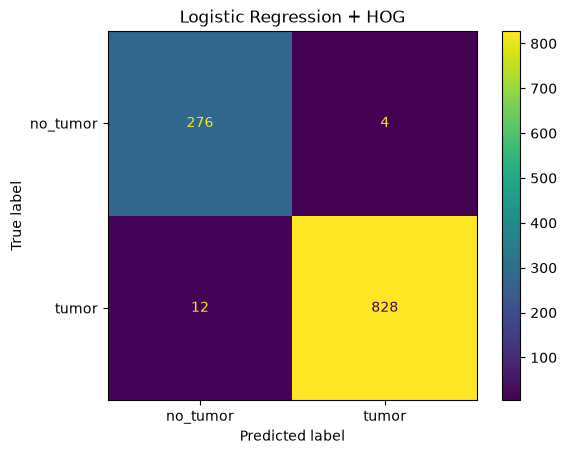

In [18]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=random_state,
    )),
])

logreg_pipeline, y_val_pred_logreg = evaluate_model(
    "Logistic Regression + HOG",
    logreg_pipeline,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)

## Linear SVM

A Linear Support Vector Machine searches for a linear decision boundary that separates the two classes.

It is a strong and efficient baseline for high-dimensional feature vectors such as HOG descriptors. The pipeline scales the features before fitting the classifier.

Linear SVM + HOG
Accuracy: 0.9803571428571428
              precision    recall  f1-score   support

    no_tumor       0.94      0.98      0.96       280
       tumor       0.99      0.98      0.99       840

    accuracy                           0.98      1120
   macro avg       0.97      0.98      0.97      1120
weighted avg       0.98      0.98      0.98      1120



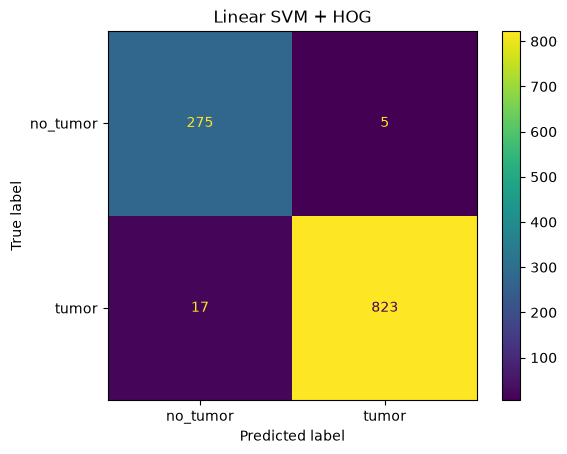

In [19]:
linear_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=10000,
        random_state=random_state,
)),
])
linear_svm_pipeline, y_val_pred_svm = evaluate_model(
    "Linear SVM + HOG",
    linear_svm_pipeline,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)



## RBF SVM

The RBF-kernel Support Vector Machine can learn nonlinear decision boundaries.

Compared with the linear SVM, it can model more complex relationships between HOG features, but it may require more computation and careful hyperparameter tuning.

RBF SVM + HOG
Accuracy: 0.9848214285714286
              precision    recall  f1-score   support

    no_tumor       0.96      0.98      0.97       280
       tumor       0.99      0.99      0.99       840

    accuracy                           0.98      1120
   macro avg       0.98      0.98      0.98      1120
weighted avg       0.98      0.98      0.98      1120



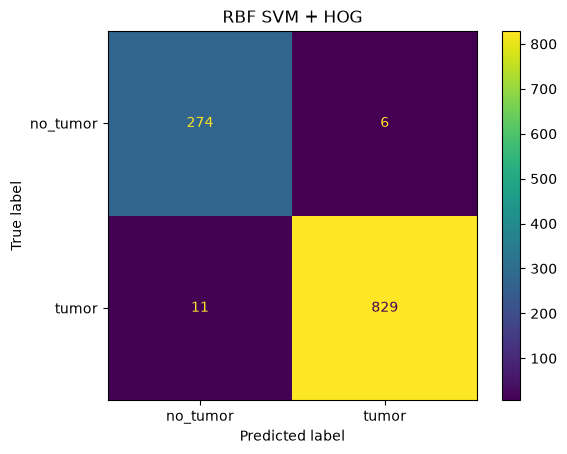

In [20]:
rbf_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=random_state,
)),
])
rbf_svm_pipeline, y_val_pred_rbf = evaluate_model(
    "RBF SVM + HOG",
    rbf_svm_pipeline,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)


## Random Forest

A Random Forest combines many decision trees. Each tree learns from a slightly different view of the training data, and the forest combines their predictions.

This model does not require a linear decision boundary and can capture feature interactions that simpler models may miss.

Random Forest + HOG
Accuracy: 0.975
              precision    recall  f1-score   support

    no_tumor       0.95      0.95      0.95       280
       tumor       0.98      0.98      0.98       840

    accuracy                           0.97      1120
   macro avg       0.97      0.97      0.97      1120
weighted avg       0.97      0.97      0.97      1120



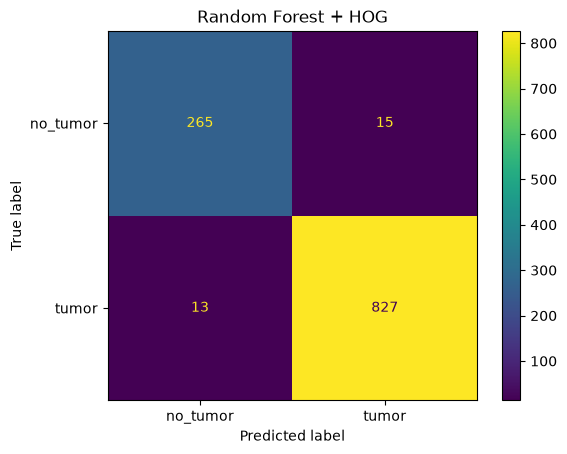

In [21]:
rf_clf = RandomForestClassifier(
    n_estimators=300,  # Number of trees in the forest; more trees can improve accuracy but increase training time.
    max_depth=None,
    class_weight="balanced",
    random_state=random_state,
    n_jobs=-1,
)
rf_clf, y_val_pred_rf = evaluate_model(
    "Random Forest + HOG",
    rf_clf,
    X_train_hog,
    y_train,
    X_val_hog,
    y_val,
)


## Comparing HOG with Raw Pixels

To measure the value of hand-crafted features, we train another Logistic Regression model using only raw pixel intensities.

This comparison answers a practical question: does describing edges and shapes with HOG help more than giving the model the resized pixel values directly?

Extracting raw features: 100%|██████████| 1120/1120 [00:04<00:00, 259.74it/s]


Logistic Regression + raw pixels
Accuracy: 0.9625
              precision    recall  f1-score   support

    no_tumor       0.91      0.94      0.93       280
       tumor       0.98      0.97      0.97       840

    accuracy                           0.96      1120
   macro avg       0.95      0.96      0.95      1120
weighted avg       0.96      0.96      0.96      1120



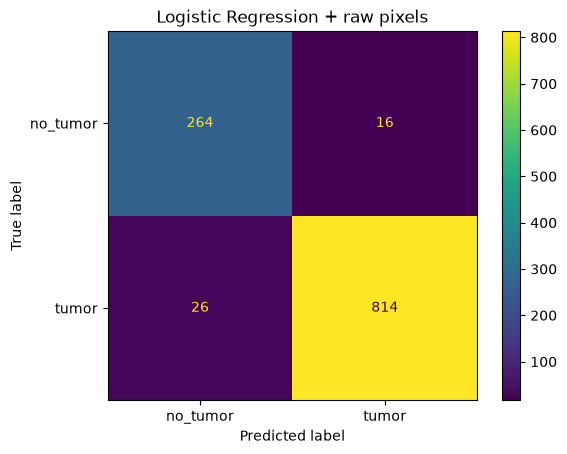

In [22]:
X_train_raw, _ = build_feature_matrix(train_df, feature_type="raw")
X_val_raw, _ = build_feature_matrix(val_df, feature_type="raw")
raw_logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=random_state,
)),
])
raw_logreg_pipeline, y_val_pred_raw = evaluate_model(
    "Logistic Regression + raw pixels",
    raw_logreg_pipeline,
    X_train_raw,
    y_train,
    X_val_raw,
    y_val,
)


## Comparing All Models

The validation predictions are collected in one table so that the models can be compared using the same metrics.

Because missing a tumor is particularly important in this task, we sort the results by tumor recall. We also keep accuracy, precision, F1-score, and the number of tumor examples.

In [23]:
from sklearn.metrics import precision_recall_fscore_support
def get_metrics_row(name: str, feature_type: str, y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1],
        zero_division=0,
)
    return {
        "model": name,
        "features": feature_type,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_tumor": precision[0],
        "recall_tumor": recall[0],
        "f1_tumor": f1[0],
        "support_tumor": support[0],
}
results = []
results.append(get_metrics_row("Dummy", "HOG", y_val, y_val_pred_dummy))
results.append(get_metrics_row("Logistic Regression", "HOG", y_val, y_val_pred_logreg))
results.append(get_metrics_row("Linear SVM", "HOG", y_val, y_val_pred_svm))
results.append(get_metrics_row("RBF SVM", "HOG", y_val, y_val_pred_rbf))
results.append(get_metrics_row("Random Forest", "HOG", y_val, y_val_pred_rf))
results.append(get_metrics_row("Logistic Regression", "raw pixels", y_val, y_val_pred_raw))

results_df = pd.DataFrame(results).sort_values("recall_tumor", ascending=False)
print(results_df)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

results_df.to_csv("outputs/tables/validation_results.csv", index=False)


                 model    features  accuracy  precision_tumor  recall_tumor  \
0                Dummy         HOG  0.750000         0.750000      1.000000   
3              RBF SVM         HOG  0.984821         0.992814      0.986905   
1  Logistic Regression         HOG  0.985714         0.995192      0.985714   
4        Random Forest         HOG  0.975000         0.982185      0.984524   
2           Linear SVM         HOG  0.980357         0.993961      0.979762   
5  Logistic Regression  raw pixels  0.962500         0.980723      0.969048   

   f1_tumor  support_tumor  
0  0.857143            840  
3  0.989851            840  
1  0.990431            840  
4  0.983353            840  
2  0.986811            840  
5  0.974850            840  


## Hyperparameter Tuning with GridSearchCV

The first model comparisons use manually selected settings. `GridSearchCV` evaluates several hyperparameter combinations using cross-validation on the training set.

Here we tune the regularization parameter of the Linear SVM and the regularization and kernel-width parameters of the RBF SVM. Recall is used as the scoring metric because detecting tumor cases is the main priority.

In [24]:
param_grid_linear_svm = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
}
linear_svm_for_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=20000,
        random_state=random_state,
    )),
])

grid_linear_svm = GridSearchCV(
    estimator=linear_svm_for_grid,
    param_grid=param_grid_linear_svm,
    scoring="recall", # recall for positive class = tumor
    cv=3,
    n_jobs=1,
    verbose=2,
)
grid_linear_svm.fit(X_train_hog, y_train)

print("Best params:", grid_linear_svm.best_params_)
print("Best CV recall:", grid_linear_svm.best_score_)

best_linear_svm = grid_linear_svm.best_estimator_
y_val_pred_best = best_linear_svm.predict(X_val_hog)

print(classification_report(
y_val,
y_val_pred_best,
target_names=["no_tumor", "tumor"],
zero_division=0,
))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ........................................clf__C=0.01; total time=   5.9s
[CV] END ........................................clf__C=0.01; total time=   8.1s
[CV] END ........................................clf__C=0.01; total time=   8.8s
[CV] END .........................................clf__C=0.1; total time=  27.5s
[CV] END .........................................clf__C=0.1; total time=  31.1s
[CV] END .........................................clf__C=0.1; total time=  32.9s
[CV] END .........................................clf__C=1.0; total time=  22.9s
[CV] END .........................................clf__C=1.0; total time=  39.3s
[CV] END .........................................clf__C=1.0; total time=  51.5s
[CV] END ........................................clf__C=10.0; total time=   1.7s
[CV] END ........................................clf__C=10.0; total time=   2.3s
[CV] END ........................................

In [25]:
param_grid_rbf = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__gamma": ["scale", 0.001, 0.01, 0.1],
}
rbf_for_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=random_state,
    )),
])

grid_rbf = GridSearchCV(
    estimator=rbf_for_grid,
    param_grid=param_grid_rbf,
    scoring="recall",
    cv=3,
    n_jobs=1,
    verbose=2,
)
grid_rbf.fit(X_train_hog, y_train)

print("Best params:", grid_rbf.best_params_)
print("Best CV recall:", grid_rbf.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .......................clf__C=0.1, clf__gamma=scale; total time=  22.9s
[CV] END .......................clf__C=0.1, clf__gamma=scale; total time=  23.2s
[CV] END .......................clf__C=0.1, clf__gamma=scale; total time=  22.6s
[CV] END .......................clf__C=0.1, clf__gamma=0.001; total time=  42.4s
[CV] END .......................clf__C=0.1, clf__gamma=0.001; total time=  42.6s
[CV] END .......................clf__C=0.1, clf__gamma=0.001; total time=  41.8s
[CV] END ........................clf__C=0.1, clf__gamma=0.01; total time=  41.9s
[CV] END ........................clf__C=0.1, clf__gamma=0.01; total time=  41.5s
[CV] END ........................clf__C=0.1, clf__gamma=0.01; total time=  41.7s
[CV] END .........................clf__C=0.1, clf__gamma=0.1; total time=  41.6s
[CV] END .........................clf__C=0.1, clf__gamma=0.1; total time=  43.3s
[CV] END .........................clf__C=0.1, cl

## Final Test Evaluation

After selecting the best configuration using training and validation data, we evaluate it once on the separate test set.

This final accuracy, classification report, and confusion matrix provide the most honest estimate of performance on unseen data.

Final test accuracy: 0.938125
              precision    recall  f1-score   support

    no_tumor       0.80      1.00      0.89       400
       tumor       1.00      0.92      0.96      1200

    accuracy                           0.94      1600
   macro avg       0.90      0.96      0.92      1600
weighted avg       0.95      0.94      0.94      1600



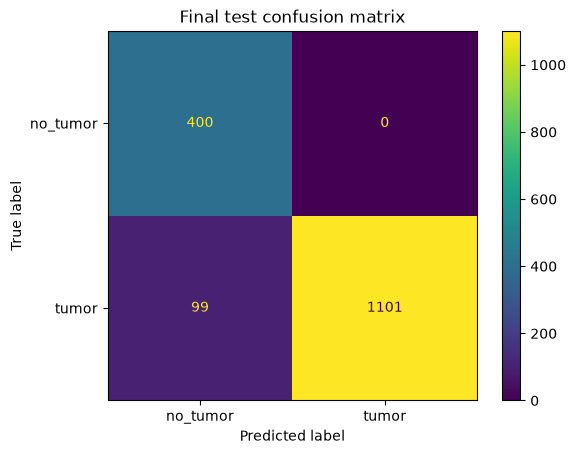

{'TN': np.int64(400), 'FP': np.int64(0), 'FN': np.int64(99), 'TP': np.int64(1101)}


In [25]:
best_model = best_linear_svm # or another selected model
y_test_pred = best_model.predict(X_test_hog)
print("Final test accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["no_tumor", "tumor"],
    zero_division=0,
))
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no_tumor", "tumor"],
)
disp.plot(values_format="d")
plt.title("Final test confusion matrix")
plt.show()
# Optional: exact TN, FP, FN, TP values.
tn, fp, fn, tp = cm.ravel()
print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

## Error Analysis

Overall metrics summarize performance, but they do not show which individual images were classified incorrectly.

We label each test example as correct, false positive, or false negative so that we can inspect the model's failure patterns.

In [26]:
test_analysis_df = test_df.copy().reset_index(drop=True)
test_analysis_df["y_true"] = y_test
test_analysis_df["y_pred"] = y_test_pred

def error_type(row):
    if row["y_true"] == 1 and row["y_pred"] == 0:
        return "false_negative"
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "false_positive"
    return "correct"
test_analysis_df["error_type"] = test_analysis_df.apply(error_type, axis=1)

print(test_analysis_df["error_type"].value_counts())

error_type
correct           1501
false_negative      99
Name: count, dtype: int64


### Visualizing False Negatives and False Positives

The final visualization displays representative examples of both error types.

- A **false negative** is a tumor image predicted as `no_tumor`.
- A **false positive** is a no-tumor image predicted as `tumor`.

These examples help us understand where the feature representation or classifier may need improvement.

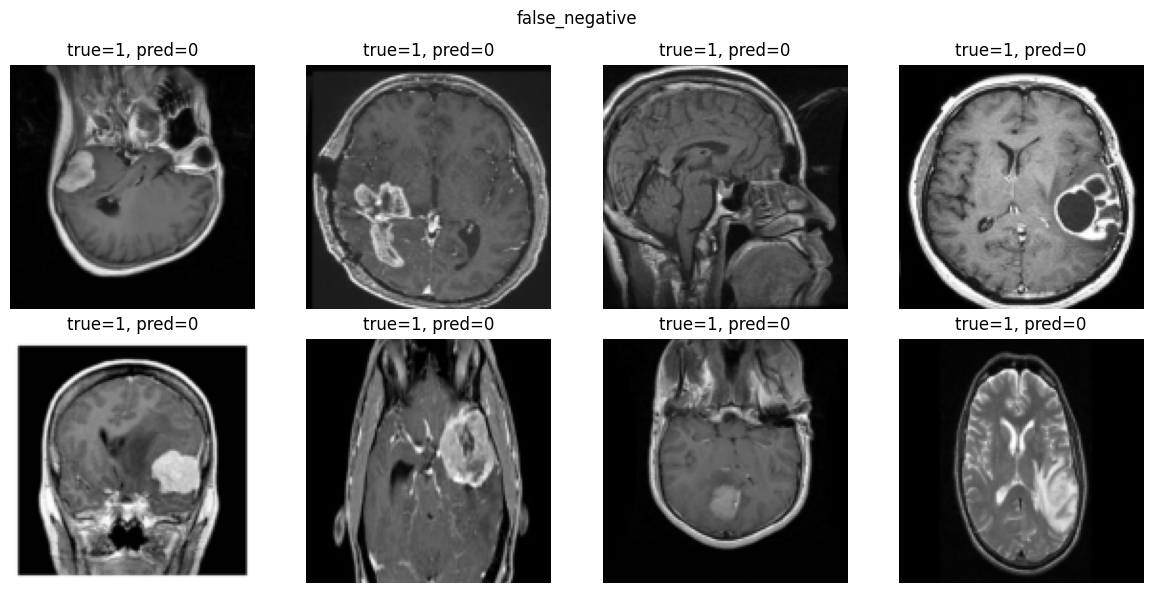

No examples for false_positive


In [28]:
def show_error_examples(df: pd.DataFrame, error_name: str, n: int = 8):
    subset = df[df["error_type"] == error_name]
    if subset.empty:
        print(f"No examples for {error_name}")
        return
    
    sample = subset.sample(n=min(n, len(subset)), random_state=random_state)

    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(12, 3 * rows))

    for i, (_, row) in enumerate(sample.iterrows(), start=1):
        image = load_and_preprocess_image(row["image_path"])
        plt.subplot(rows, cols, i)
        plt.imshow(image, cmap="gray")
        plt.title(f"true={row['y_true']}, pred={row['y_pred']}")
        plt.axis("off")

    plt.suptitle(error_name)
    plt.tight_layout()
    plt.show()

show_error_examples(test_analysis_df, "false_negative", n=8)
show_error_examples(test_analysis_df, "false_positive", n=8)
